# Stationarity in Time Series Analysis

## 1. What is Stationarity?

A time series is **stationary** if its statistical properties do not change over time. This is a foundational assumption for most time series models (ARIMA, SARIMA, etc.).

### Types of Stationarity

| Type | Definition |
|------|------------|
| **Strict Stationarity** | The joint distribution of $(x_t, x_{t+1}, ..., x_{t+k})$ is identical to $(x_{t+h}, x_{t+h+1}, ..., x_{t+h+k})$ for any $h, k$. All moments are time-invariant. |
| **Weak Stationarity (Covariance Stationarity)** | Only requires: (1) constant mean, (2) constant variance, (3) autocovariance depends only on lag $k$, not on time $t$. |

> In practice, we almost always work with **weak stationarity**.


## 2. Why Does Stationarity Matter?

Non-stationary series can produce **spurious regression** — two unrelated non-stationary series may appear highly correlated simply because they both trend over time.

**Modeling implications:**
- ARMA models assume stationarity
- Non-stationary series often require **differencing** before modeling
- Forecasts from non-stationary models can diverge to infinity

**Visual cues of non-stationarity:**
- Obvious trend (mean changes over time)
- Changing variance (volatility clustering)
- Seasonal patterns
- ACF that decays very slowly
- 

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tools.sm_exceptions import InterpolationWarning

# Suppress KPSS p-value lookup warnings
warnings.filterwarnings("ignore", category=InterpolationWarning)

np.random.seed(42)

N = 300
t = np.arange(N)

# 1. Stationary: White Noise
white_noise = np.random.normal(loc=5, scale=2, size=N)

# 2. Non-Stationary: Deterministic Trend
trend_series = 0.08 * t + np.random.normal(0, 1.5, N)

# 3. Non-Stationary: Random Walk (unit root)
random_walk = np.cumsum(np.random.normal(0, 1, N))

# 4. Non-Stationary: Changing Variance (heteroscedastic)
hetero_series = np.random.normal(0, 1 + 0.02 * t, N)

# 5. Stationary: AR(2) process
ar_params = np.array([1, -0.6, -0.3])
ma_params = np.array([1])
ar_process = ArmaProcess(ar_params, ma_params)
ar_stationary = ar_process.generate_sample(nsample=N)

# 6. Non-Stationary: Seasonal + Trend
seasonal_trend = 2 * np.sin(2 * np.pi * t / 12) + 0.05 * t + np.random.normal(0, 0.5, N)

series_collection = {
    "White Noise (Stationary)": white_noise,
    "Deterministic Trend (Non-Stationary)": trend_series,
    "Random Walk (Non-Stationary)": random_walk,
    "Heteroscedastic (Non-Stationary)": hetero_series,
    "AR(2) Process (Stationary)": ar_stationary,
    "Seasonal + Trend (Non-Stationary)": seasonal_trend
}

print("Synthetic series generated:")
for name, data in series_collection.items():
    print(f"  {name}: mean={data.mean():.2f}, std={data.std():.2f}")


Synthetic series generated:
  White Noise (Stationary): mean=4.99, std=1.97
  Deterministic Trend (Non-Stationary): mean=11.93, std=6.96
  Random Walk (Non-Stationary): mean=3.93, std=5.84
  Heteroscedastic (Non-Stationary): mean=0.37, std=4.54
  AR(2) Process (Stationary): mean=0.70, std=1.98
  Seasonal + Trend (Non-Stationary): mean=7.50, std=4.56


## 3. Visual Inspection: Time Series Plots

The first step in checking stationarity is always **visual inspection**. Look for:
- Trends in the mean
- Changing variance
- Seasonal cycles
- Structural breaks
- 

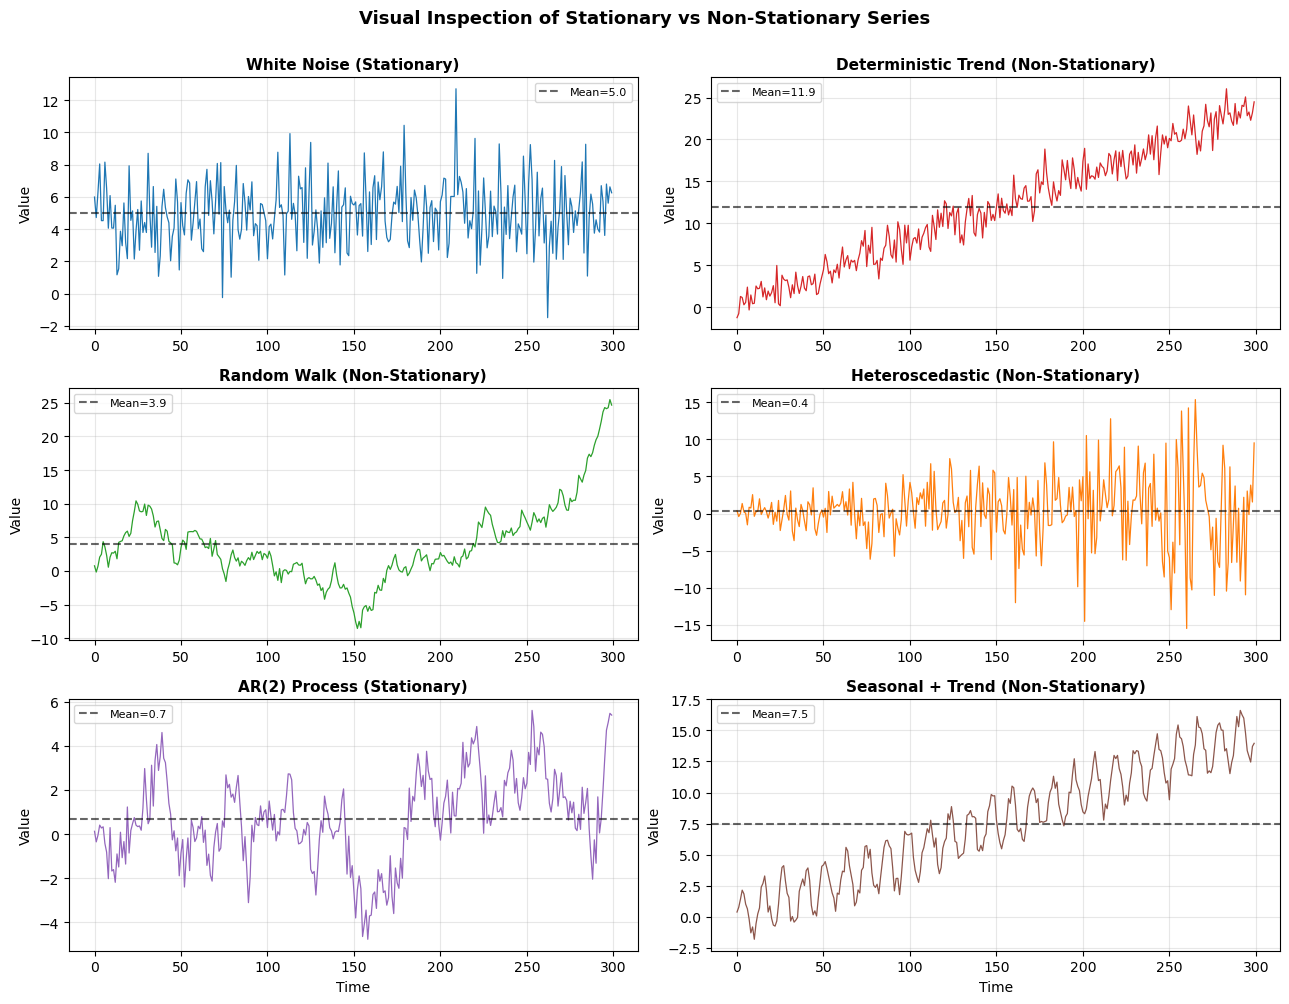

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(13, 10))
axes = axes.flatten()

colors = ['tab:blue', 'tab:red', 'tab:green', 'tab:orange', 'tab:purple', 'tab:brown']

for ax, ((name, data), color) in zip(axes, zip(series_collection.items(), colors)):
    ax.plot(t, data, color=color, linewidth=0.9)
    ax.axhline(y=data.mean(), color='black', linestyle='--', alpha=0.6, label=f"Mean={data.mean():.1f}")
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_ylabel("Value")
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

for ax in axes[-2:]:
    ax.set_xlabel("Time")

plt.suptitle("Visual Inspection of Stationary vs Non-Stationary Series", 
             fontsize=13, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()


## 4. Rolling Statistics: Moving Mean and Variance

A powerful diagnostic is to compute **rolling (moving) statistics** over a window. If the rolling mean or variance drifts significantly, the series is likely non-stationary.


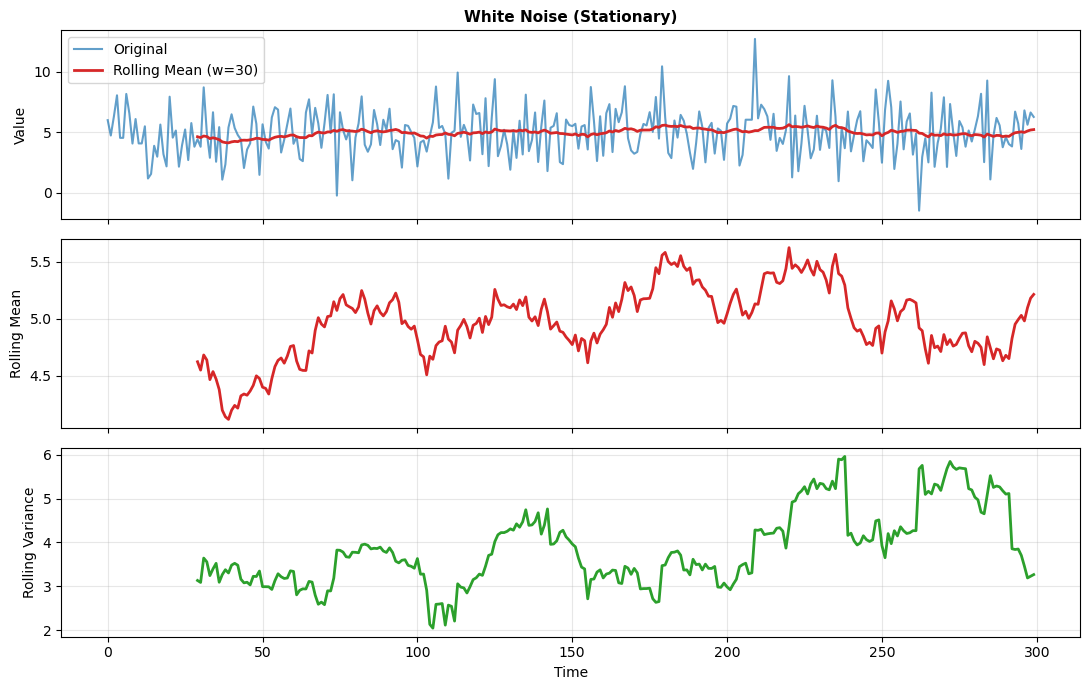

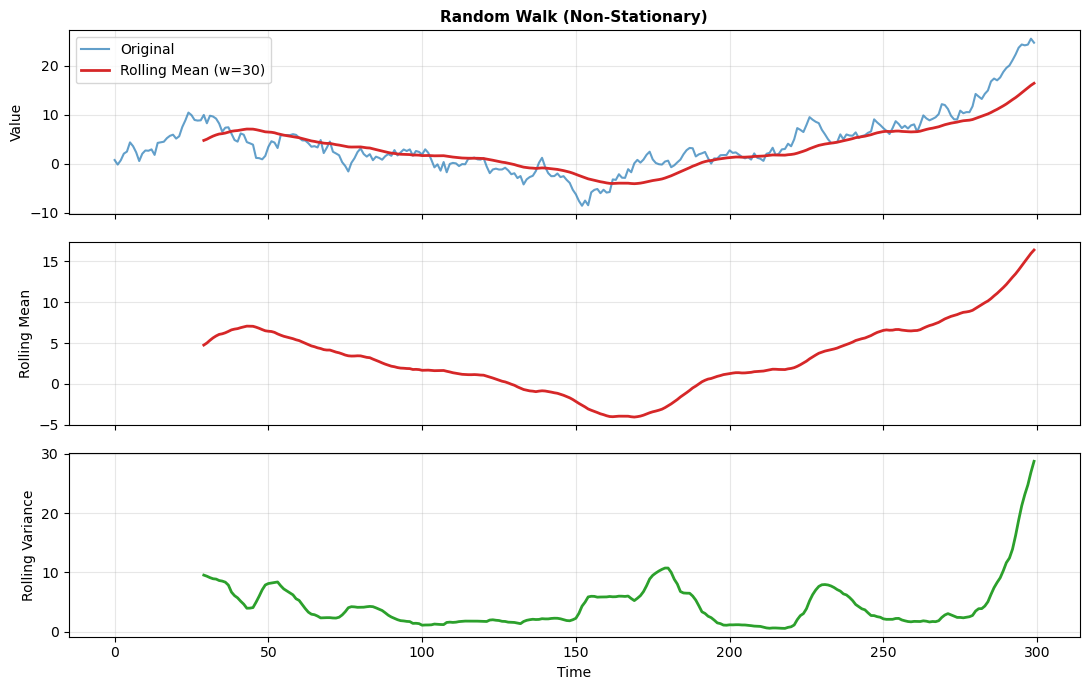

In [16]:
def plot_rolling_stats(data, name, window=30):
    """
    Plot original series with rolling mean and rolling std.
    """
    rolling_mean = np.convolve(data, np.ones(window)/window, mode='valid')
    rolling_var = np.array([
        np.var(data[i:i+window]) 
        for i in range(len(data) - window + 1)
    ])
    
    fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
    
    # Original series
    axes[0].plot(t, data, color='tab:blue', alpha=0.7, label='Original')
    axes[0].plot(t[window-1:], rolling_mean, color='tab:red', linewidth=2, label=f'Rolling Mean (w={window})')
    axes[0].set_title(name, fontsize=11, fontweight='bold')
    axes[0].set_ylabel("Value")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Rolling mean only
    axes[1].plot(t[window-1:], rolling_mean, color='tab:red', linewidth=2)
    axes[1].set_ylabel("Rolling Mean")
    axes[1].grid(True, alpha=0.3)
    
    # Rolling variance
    axes[2].plot(t[window-1:], rolling_var, color='tab:green', linewidth=2)
    axes[2].set_ylabel("Rolling Variance")
    axes[2].set_xlabel("Time")
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


# Compare a stationary and a non-stationary example
plot_rolling_stats(white_noise, "White Noise (Stationary)", window=30)
plot_rolling_stats(random_walk, "Random Walk (Non-Stationary)", window=30)


## 5. Augmented Dickey-Fuller (ADF) Test

The ADF test checks for the presence of a **unit root** (a common cause of non-stationarity).

**Hypotheses:**
- $H_0$: The series has a unit root (**non-stationary**)
- $H_1$: The series is stationary (or trend-stationary)

**Decision rule:** If p-value < 0.05, reject $H_0$ → series is stationary.

The test regression:
$$\Delta x_t = \alpha + \beta t + \gamma x_{t-1} + \delta_1 \Delta x_{t-1} + ... + \epsilon_t$$

where $\gamma = 0$ implies a unit root.


In [17]:
def adf_test_report(data, name):
    """
    Perform ADF test and return formatted results.
    """
    result = adfuller(data, autolag='AIC')
    
    print("=" * 55)
    print(f"ADF Test Results: {name}")
    print("=" * 55)
    print(f"ADF Statistic:        {result[0]:.6f}")
    print(f"p-value:              {result[1]:.6f}")
    print(f"Number of Lags Used:  {result[2]}")
    print(f"Number of Observations: {result[3]}")
    print("Critical Values:")
    for key, val in result[4].items():
        print(f"  {key}: {val:.4f}")
    
    if result[1] < 0.05:
        print("=> CONCLUSION: Reject H0. Series is STATIONARY.")
    else:
        print("=> CONCLUSION: Fail to reject H0. Series is NON-STATIONARY.")
    print()


# Run ADF on all series
for name, data in series_collection.items():
    adf_test_report(data, name)


ADF Test Results: White Noise (Stationary)
ADF Statistic:        -18.631589
p-value:              0.000000
Number of Lags Used:  0
Number of Observations: 299
Critical Values:
  1%: -3.4524
  5%: -2.8713
  10%: -2.5719
=> CONCLUSION: Reject H0. Series is STATIONARY.

ADF Test Results: Deterministic Trend (Non-Stationary)
ADF Statistic:        0.205702
p-value:              0.972580
Number of Lags Used:  14
Number of Observations: 285
Critical Values:
  1%: -3.4535
  5%: -2.8717
  10%: -2.5722
=> CONCLUSION: Fail to reject H0. Series is NON-STATIONARY.

ADF Test Results: Random Walk (Non-Stationary)
ADF Statistic:        0.628800
p-value:              0.988304
Number of Lags Used:  0
Number of Observations: 299
Critical Values:
  1%: -3.4524
  5%: -2.8713
  10%: -2.5719
=> CONCLUSION: Fail to reject H0. Series is NON-STATIONARY.

ADF Test Results: Heteroscedastic (Non-Stationary)
ADF Statistic:        -7.270479
p-value:              0.000000
Number of Lags Used:  5
Number of Observation

## 6. KPSS Test (Kwiatkowski-Phillips-Schmidt-Shin)

The KPSS test is a complement to ADF. It tests the **null hypothesis of stationarity** directly — opposite to ADF!

**Hypotheses:**
- $H_0$: The series is stationary (or trend-stationary)
- $H_1$: The series has a unit root (non-stationary)

**Decision rule:** If p-value < 0.05, reject $H_0$ → series is non-stationary.

> **Best practice:** Use both ADF and KPSS together. Conflicting results often indicate **difference-stationary** vs **trend-stationary** behavior.


In [18]:
def kpss_test_report(data, name, regression='c'):
    """
    Perform KPSS test and return formatted results.
    regression='c' for stationary around constant,
    regression='ct' for trend-stationary.
    """
    result = kpss(data, regression=regression, nlags='auto')
    
    print("=" * 55)
    print(f"KPSS Test Results: {name} (regression={regression})")
    print("=" * 55)
    print(f"KPSS Statistic:       {result[0]:.6f}")
    print(f"p-value:              {result[1]:.6f}")
    print(f"Number of Lags:       {result[2]}")
    print("Critical Values:")
    for key, val in result[3].items():
        print(f"  {key}: {val:.4f}")
    
    if result[1] < 0.05:
        print("=> CONCLUSION: Reject H0. Series is NON-STATIONARY.")
    else:
        print("=> CONCLUSION: Fail to reject H0. Series is STATIONARY.")
    print()


# Run KPSS on all series
for name, data in series_collection.items():
    kpss_test_report(data, name, regression='c')


KPSS Test Results: White Noise (Stationary) (regression=c)
KPSS Statistic:       0.181477
p-value:              0.100000
Number of Lags:       1
Critical Values:
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390
=> CONCLUSION: Fail to reject H0. Series is STATIONARY.

KPSS Test Results: Deterministic Trend (Non-Stationary) (regression=c)
KPSS Statistic:       2.816964
p-value:              0.010000
Number of Lags:       10
Critical Values:
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390
=> CONCLUSION: Reject H0. Series is NON-STATIONARY.

KPSS Test Results: Random Walk (Non-Stationary) (regression=c)
KPSS Statistic:       0.953721
p-value:              0.010000
Number of Lags:       10
Critical Values:
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390
=> CONCLUSION: Reject H0. Series is NON-STATIONARY.

KPSS Test Results: Heteroscedastic (Non-Stationary) (regression=c)
KPSS Statistic:       0.074907
p-value:              0.100000
Number of Lags:       3
Critical Values

## 7. Side-by-Side Test Comparison

Let's create a summary table comparing ADF and KPSS results across all series to see how they agree or disagree.


In [19]:
def run_both_tests(data):
    """
    Run both ADF and KPSS and return conclusions.
    """
    # ADF: H0 = non-stationary
    adf_result = adfuller(data, autolag='AIC')
    adf_stationary = adf_result[1] < 0.05
    
    # KPSS: H0 = stationary
    kpss_result = kpss(data, regression='c', nlags='auto')
    kpss_stationary = kpss_result[1] >= 0.05  # fail to reject = stationary
    
    return adf_stationary, kpss_stationary, adf_result[0], adf_result[1], kpss_result[0], kpss_result[1]


print("-" * 75)
print(f"{'Series':<35} {'ADF (p)':<12} {'KPSS (p)':<12} {'Consensus'}")
print("-" * 75)

for name, data in series_collection.items():
    adf_stat, kpss_stat, adf_stat_val, adf_p, kpss_stat_val, kpss_p = run_both_tests(data)
    
    adf_label = "Stationary" if adf_stat else "Non-Stat"
    kpss_label = "Stationary" if kpss_stat else "Non-Stat"
    
    if adf_stat and kpss_stat:
        consensus = "STATIONARY"
    elif not adf_stat and not kpss_stat:
        consensus = "NON-STATIONARY"
    else:
        consensus = "AMBIGUOUS"
    
    print(f"{name:<35} {adf_p:<12.4f} {kpss_p:<12.4f} {consensus}")

print("-" * 75)


---------------------------------------------------------------------------
Series                              ADF (p)      KPSS (p)     Consensus
---------------------------------------------------------------------------
White Noise (Stationary)            0.0000       0.1000       STATIONARY
Deterministic Trend (Non-Stationary) 0.9726       0.0100       NON-STATIONARY
Random Walk (Non-Stationary)        0.9883       0.0100       NON-STATIONARY
Heteroscedastic (Non-Stationary)    0.0000       0.1000       STATIONARY
AR(2) Process (Stationary)          0.0180       0.0194       AMBIGUOUS
Seasonal + Trend (Non-Stationary)   0.9132       0.0100       NON-STATIONARY
---------------------------------------------------------------------------


## 8. ACF as a Stationarity Diagnostic

A classic rule of thumb: **stationary series have ACF that drops to zero quickly**, while non-stationary series show ACF that decays very slowly.


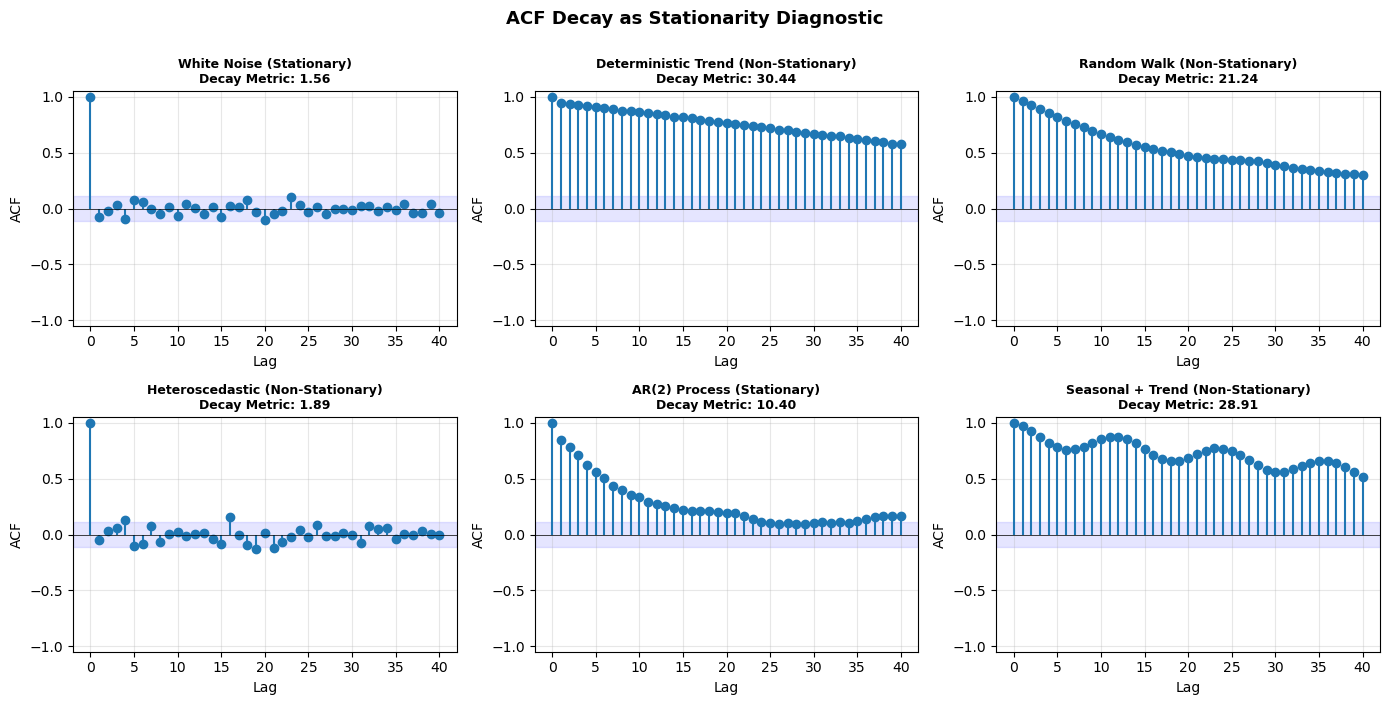

In [20]:
def manual_acf(data, max_lags=40):
    """
    Compute sample autocorrelation function manually.
    """
    N = len(data)
    max_lags = min(max_lags, N - 1)
    x_centered = data - data.mean()
    autocov = np.zeros(max_lags + 1)
    for k in range(max_lags + 1):
        autocov[k] = np.sum(x_centered[k:] * x_centered[:N-k]) / N
    return autocov / autocov[0]


fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
max_lags = 40
lags = np.arange(max_lags + 1)
conf = 1.96 / np.sqrt(N)

for ax, (name, data) in zip(axes, series_collection.items()):
    acf_vals = manual_acf(data, max_lags)
    
    ax.stem(lags, acf_vals, basefmt=" ")
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axhspan(-conf, conf, color='blue', alpha=0.1)
    
    # Compute "decay metric": sum of absolute ACF values
    decay_metric = np.sum(np.abs(acf_vals[1:]))
    
    ax.set_title(f"{name}\nDecay Metric: {decay_metric:.2f}", fontsize=9, fontweight='bold')
    ax.set_xlabel("Lag")
    ax.set_ylabel("ACF")
    ax.set_ylim(-1.05, 1.05)
    ax.grid(True, alpha=0.3)

plt.suptitle("ACF Decay as Stationarity Diagnostic", fontsize=13, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()


## 9. Making a Non-Stationary Series Stationary

When a series is non-stationary, we can apply transformations:

| Technique | When to Use | Effect |
|-----------|-------------|--------|
| **Differencing** $\nabla x_t = x_t - x_{t-1}$ | Unit root, random walk | Removes stochastic trends |
| **Log transform** $\log(x_t)$ | Exponential growth, changing variance | Stabilizes variance |
| **Detrending** $x_t - \hat{\beta}t$ | Deterministic trend | Removes linear trend |
| **Seasonal differencing** $x_t - x_{t-s}$ | Seasonal non-stationarity | Removes seasonal patterns |

Let's demonstrate on the **Random Walk** and **Trend** series.


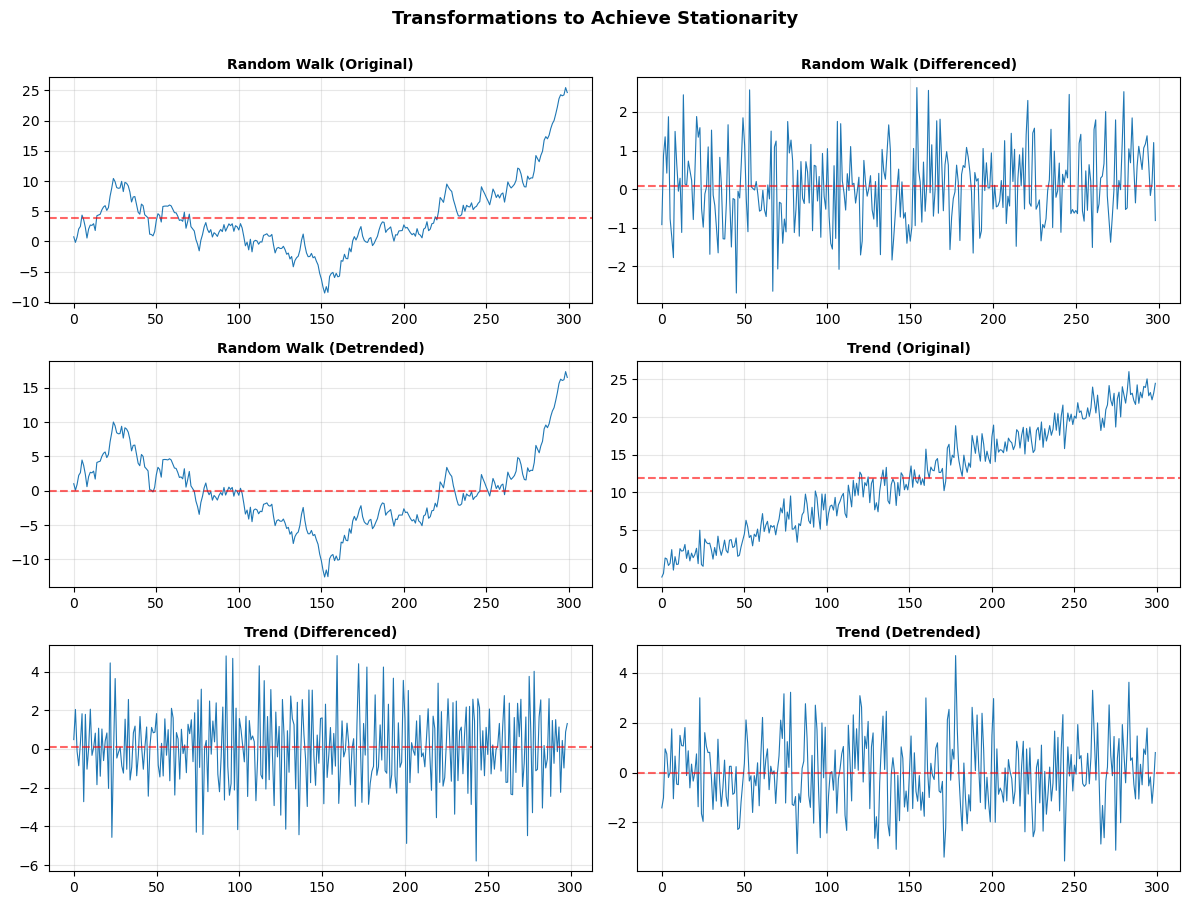

In [21]:
# Transformations on Random Walk
rw_diff = np.diff(random_walk)  # First difference
rw_detrended = random_walk - np.polyval(np.polyfit(t, random_walk, 1), t)

# Transformations on Trend series
trend_diff = np.diff(trend_series)
trend_detrended = trend_series - np.polyval(np.polyfit(t, trend_series, 1), t)

# Log transform on exponential-like series (create one)
exp_series = np.exp(0.01 * t) + np.random.normal(0, 0.5, N)
log_exp = np.log(exp_series)

transformations = {
    "Random Walk (Original)": random_walk,
    "Random Walk (Differenced)": rw_diff,
    "Random Walk (Detrended)": rw_detrended,
    "Trend (Original)": trend_series,
    "Trend (Differenced)": trend_diff,
    "Trend (Detrended)": trend_detrended,
}

fig, axes = plt.subplots(3, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, (name, data) in zip(axes, transformations.items()):
    t_plot = np.arange(len(data))
    ax.plot(t_plot, data, color='tab:blue', linewidth=0.8)
    ax.axhline(y=data.mean(), color='red', linestyle='--', alpha=0.6)
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle("Transformations to Achieve Stationarity", fontsize=13, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()


## 10. Testing Transformed Series

Let's verify that our transformations actually worked by re-running the ADF and KPSS tests.


In [22]:
transformed_tests = {
    "Random Walk (Original)": random_walk,
    "Random Walk (Differenced)": rw_diff,
    "Trend (Original)": trend_series,
    "Trend (Detrended)": trend_detrended,
    "Seasonal+Trend (Original)": seasonal_trend,
    "Seasonal+Trend (Differenced)": np.diff(seasonal_trend),
}

print("=" * 70)
print(f"{'Series':<35} {'ADF p-value':<15} {'Stationary?'}")
print("=" * 70)

for name, data in transformed_tests.items():
    result = adfuller(data, autolag='AIC')
    is_stationary = "YES" if result[1] < 0.05 else "NO"
    print(f"{name:<35} {result[1]:<15.6f} {is_stationary}")

print("=" * 70)


Series                              ADF p-value     Stationary?
Random Walk (Original)              0.988304        NO
Random Walk (Differenced)           0.000000        YES
Trend (Original)                    0.972580        NO
Trend (Detrended)                   0.000000        YES
Seasonal+Trend (Original)           0.913221        NO
Seasonal+Trend (Differenced)        0.000000        YES


## 11. Rolling Statistics After Differencing

A before/after comparison showing how differencing stabilizes the rolling mean and variance.


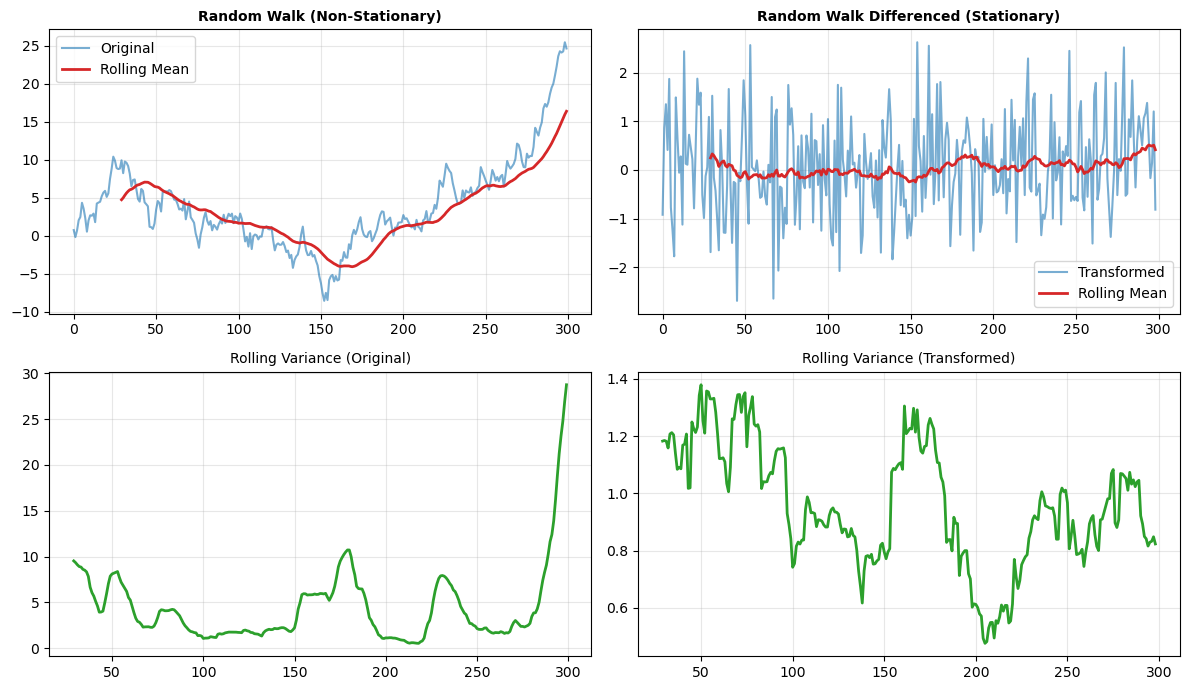

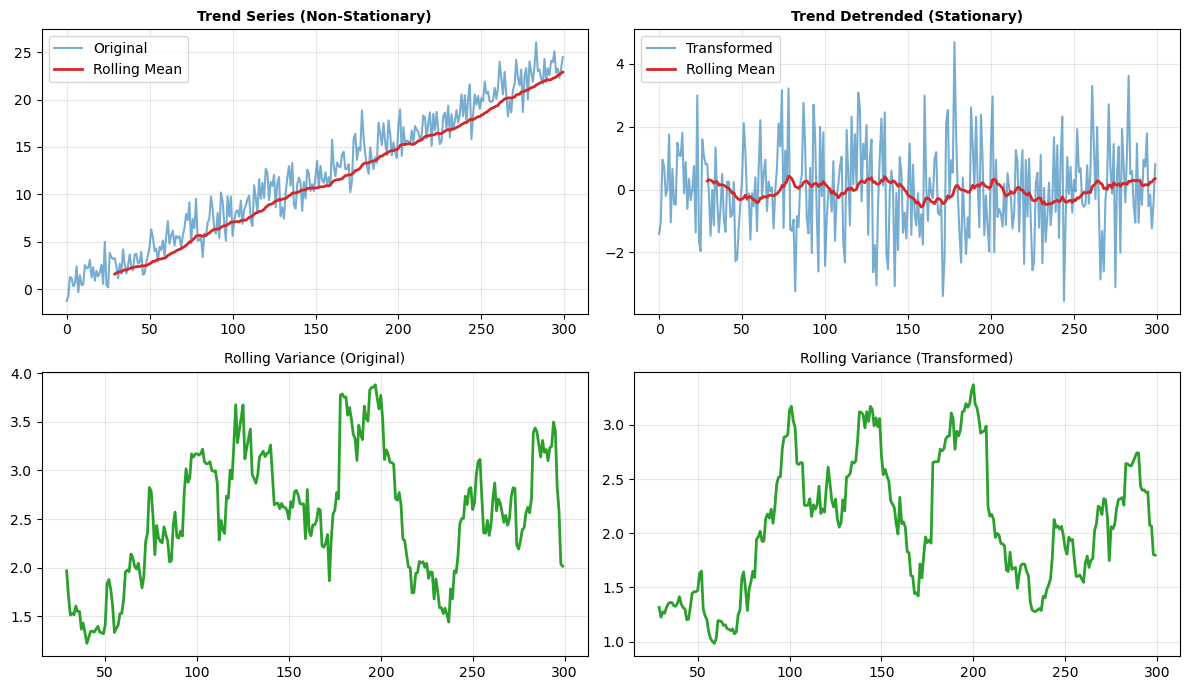

In [23]:
def compare_before_after(original, transformed, title_orig, title_trans, window=30):
    """
    Side-by-side rolling statistics comparison.
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    
    # Original series
    axes[0, 0].plot(original, color='tab:blue', alpha=0.6, label='Original')
    roll_mean_orig = np.convolve(original, np.ones(window)/window, mode='valid')
    axes[0, 0].plot(np.arange(window-1, len(original)), roll_mean_orig, 
                    color='tab:red', linewidth=2, label='Rolling Mean')
    axes[0, 0].set_title(title_orig, fontsize=10, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    roll_var_orig = np.array([np.var(original[i:i+window]) for i in range(len(original)-window+1)])
    axes[1, 0].plot(np.arange(window-1, len(original)), roll_var_orig, 
                    color='tab:green', linewidth=2)
    axes[1, 0].set_title("Rolling Variance (Original)", fontsize=10)
    axes[1, 0].grid(True, alpha=0.3)
    
    # Transformed series
    axes[0, 1].plot(transformed, color='tab:blue', alpha=0.6, label='Transformed')
    roll_mean_trans = np.convolve(transformed, np.ones(window)/window, mode='valid')
    axes[0, 1].plot(np.arange(window-1, len(transformed)), roll_mean_trans, 
                    color='tab:red', linewidth=2, label='Rolling Mean')
    axes[0, 1].set_title(title_trans, fontsize=10, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    roll_var_trans = np.array([np.var(transformed[i:i+window]) for i in range(len(transformed)-window+1)])
    axes[1, 1].plot(np.arange(window-1, len(transformed)), roll_var_trans, 
                    color='tab:green', linewidth=2)
    axes[1, 1].set_title("Rolling Variance (Transformed)", fontsize=10)
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


compare_before_after(random_walk, rw_diff, 
                     "Random Walk (Non-Stationary)", 
                     "Random Walk Differenced (Stationary)")

compare_before_after(trend_series, trend_detrended,
                     "Trend Series (Non-Stationary)",
                     "Trend Detrended (Stationary)")


## 12. Distribution Comparison: Stationary vs Non-Stationary

A stationary series should have a stable distribution over time. We can verify this by comparing histograms of the first half vs second half.


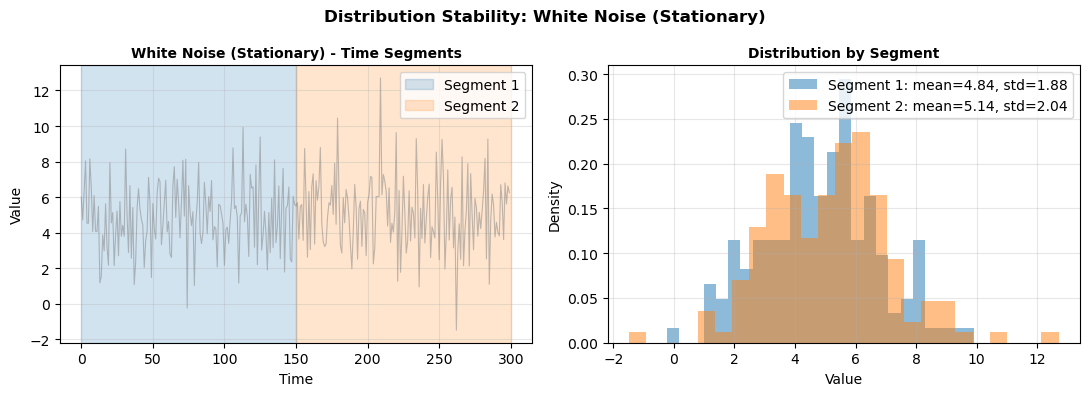

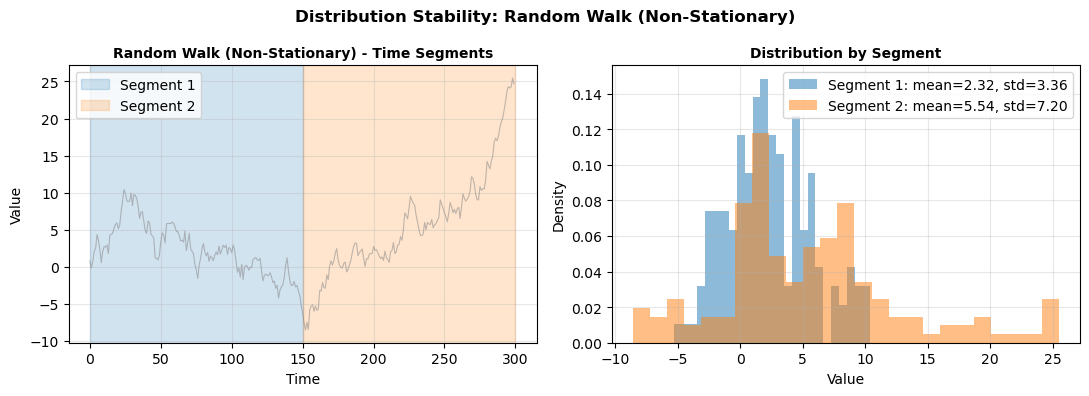

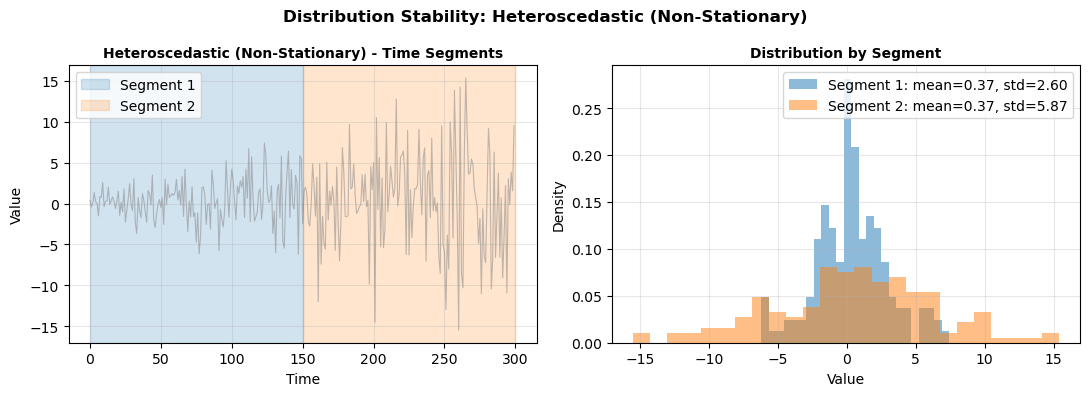

In [24]:
def plot_distribution_stability(data, name, n_splits=2):
    """
    Plot histograms of different time segments to check distribution stability.
    """
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    
    n = len(data)
    split = n // n_splits
    
    colors = ['tab:blue', 'tab:orange']
    
    # Time series with segments highlighted
    axes[0].plot(data, color='gray', alpha=0.5, linewidth=0.8)
    for i in range(n_splits):
        start = i * split
        end = (i + 1) * split if i < n_splits - 1 else n
        axes[0].axvspan(start, end, alpha=0.2, color=colors[i], 
                        label=f'Segment {i+1}')
    axes[0].set_title(f"{name} - Time Segments", fontsize=10, fontweight='bold')
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("Value")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Overlapping histograms
    for i in range(n_splits):
        start = i * split
        end = (i + 1) * split if i < n_splits - 1 else n
        segment = data[start:end]
        axes[1].hist(segment, bins=25, alpha=0.5, color=colors[i], 
                     density=True, label=f'Segment {i+1}: mean={segment.mean():.2f}, std={segment.std():.2f}')
    
    axes[1].set_title("Distribution by Segment", fontsize=10, fontweight='bold')
    axes[1].set_xlabel("Value")
    axes[1].set_ylabel("Density")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle(f"Distribution Stability: {name}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Compare stationary vs non-stationary
plot_distribution_stability(white_noise, "White Noise (Stationary)")
plot_distribution_stability(random_walk, "Random Walk (Non-Stationary)")
plot_distribution_stability(hetero_series, "Heteroscedastic (Non-Stationary)")


## 13. Summary: Stationarity Checklist

Use this checklist when analyzing any time series:

| Check | Method | Stationary if... |
|-------|--------|----------------|
| **Visual inspection** | Time plot | No trend, constant variance |
| **Rolling stats** | Moving mean/var | Stable over time |
| **ADF test** | `adfuller()` | p-value < 0.05 |
| **KPSS test** | `kpss()` | p-value > 0.05 |
| **ACF decay** | Correlogram | Drops quickly to zero |
| **Distribution** | Segment histograms | Similar across time |

### Remedies for Non-Stationarity:
1. **Trend** → Detrend or difference
2. **Seasonality** → Seasonal differencing or decomposition
3. **Changing variance** → Log transform or Box-Cox
4. **Unit root** → Differencing (usually first difference is enough)
5. 

In [25]:
# Final summary: all tests in one table
print("=" * 80)
print("COMPLETE STATIONARITY SUMMARY")
print("=" * 80)
print(f"{'Series':<38} {'ADF p':<10} {'KPSS p':<10} {'Visual':<12} {'ACF Decay'}")
print("-" * 80)

for name, data in series_collection.items():
    adf_p = adfuller(data, autolag='AIC')[1]
    kpss_p = kpss(data, regression='c', nlags='auto')[1]
    
    acf_vals = manual_acf(data, 30)
    decay = np.sum(np.abs(acf_vals[1:]))
    decay_label = "Slow" if decay > 8 else "Fast"
    
    visual = "Non-Stat" if "Non-Stationary" in name else "Stationary"
    
    adf_str = f"{adf_p:.4f}"
    kpss_str = f"{kpss_p:.4f}"
    
    print(f"{name:<38} {adf_str:<10} {kpss_str:<10} {visual:<12} {decay_label}")

print("=" * 80)
print("\nAll cells are ready. Copy each block into its corresponding Jupyter cell!")


COMPLETE STATIONARITY SUMMARY
Series                                 ADF p      KPSS p     Visual       ACF Decay
--------------------------------------------------------------------------------
White Noise (Stationary)               0.0000     0.1000     Stationary   Fast
Deterministic Trend (Non-Stationary)   0.9726     0.0100     Non-Stat     Slow
Random Walk (Non-Stationary)           0.9883     0.0100     Non-Stat     Slow
Heteroscedastic (Non-Stationary)       0.0000     0.1000     Non-Stat     Fast
AR(2) Process (Stationary)             0.0180     0.0194     Stationary   Slow
Seasonal + Trend (Non-Stationary)      0.9132     0.0100     Non-Stat     Slow

All cells are ready. Copy each block into its corresponding Jupyter cell!
